In [3]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [4]:
pd.set_option('display.max_columns', None)
df_eval = pd.read_csv("data/extrait_eval.csv")
df_eval["id_employee"] = df_eval['eval_number'].str.replace('E_', '')
df_eval.drop('eval_number', axis=1, inplace=True)
df_eval.head()


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,id_employee
0,2,3,2,4,1,1,3,Oui,11 %,1
1,3,2,2,2,4,3,4,Non,23 %,2
2,4,2,1,3,2,3,3,Oui,15 %,4
3,4,3,1,3,3,3,3,Oui,11 %,5
4,1,3,1,2,4,3,3,Non,12 %,7


In [5]:
df_sirh = pd.read_csv("data/extrait_sirh.csv")
df_sirh["id_employee"] = df_sirh["id_employee"].astype(str)
df_sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [6]:
df_merge_temp = df_sirh.merge(df_eval, how = "inner", on = ["id_employee"])
df_merge_temp.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %


In [7]:
df_sondage = pd.read_csv("data/extrait_sondage.csv")
df_sondage['id_employee'] = df_sondage['code_sondage'].astype(str)
df_sondage.drop('code_sondage', axis=1, inplace=True)
df_sondage.head()
#print(str(df_sondage['code_sondage']))

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,id_employee
0,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1
1,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7,2
2,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0,4
3,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0,5
4,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2,7


In [8]:
df_merge = df_merge_temp.merge(df_sondage, how = "inner", on = ["id_employee"])

In [9]:
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


<Axes: >

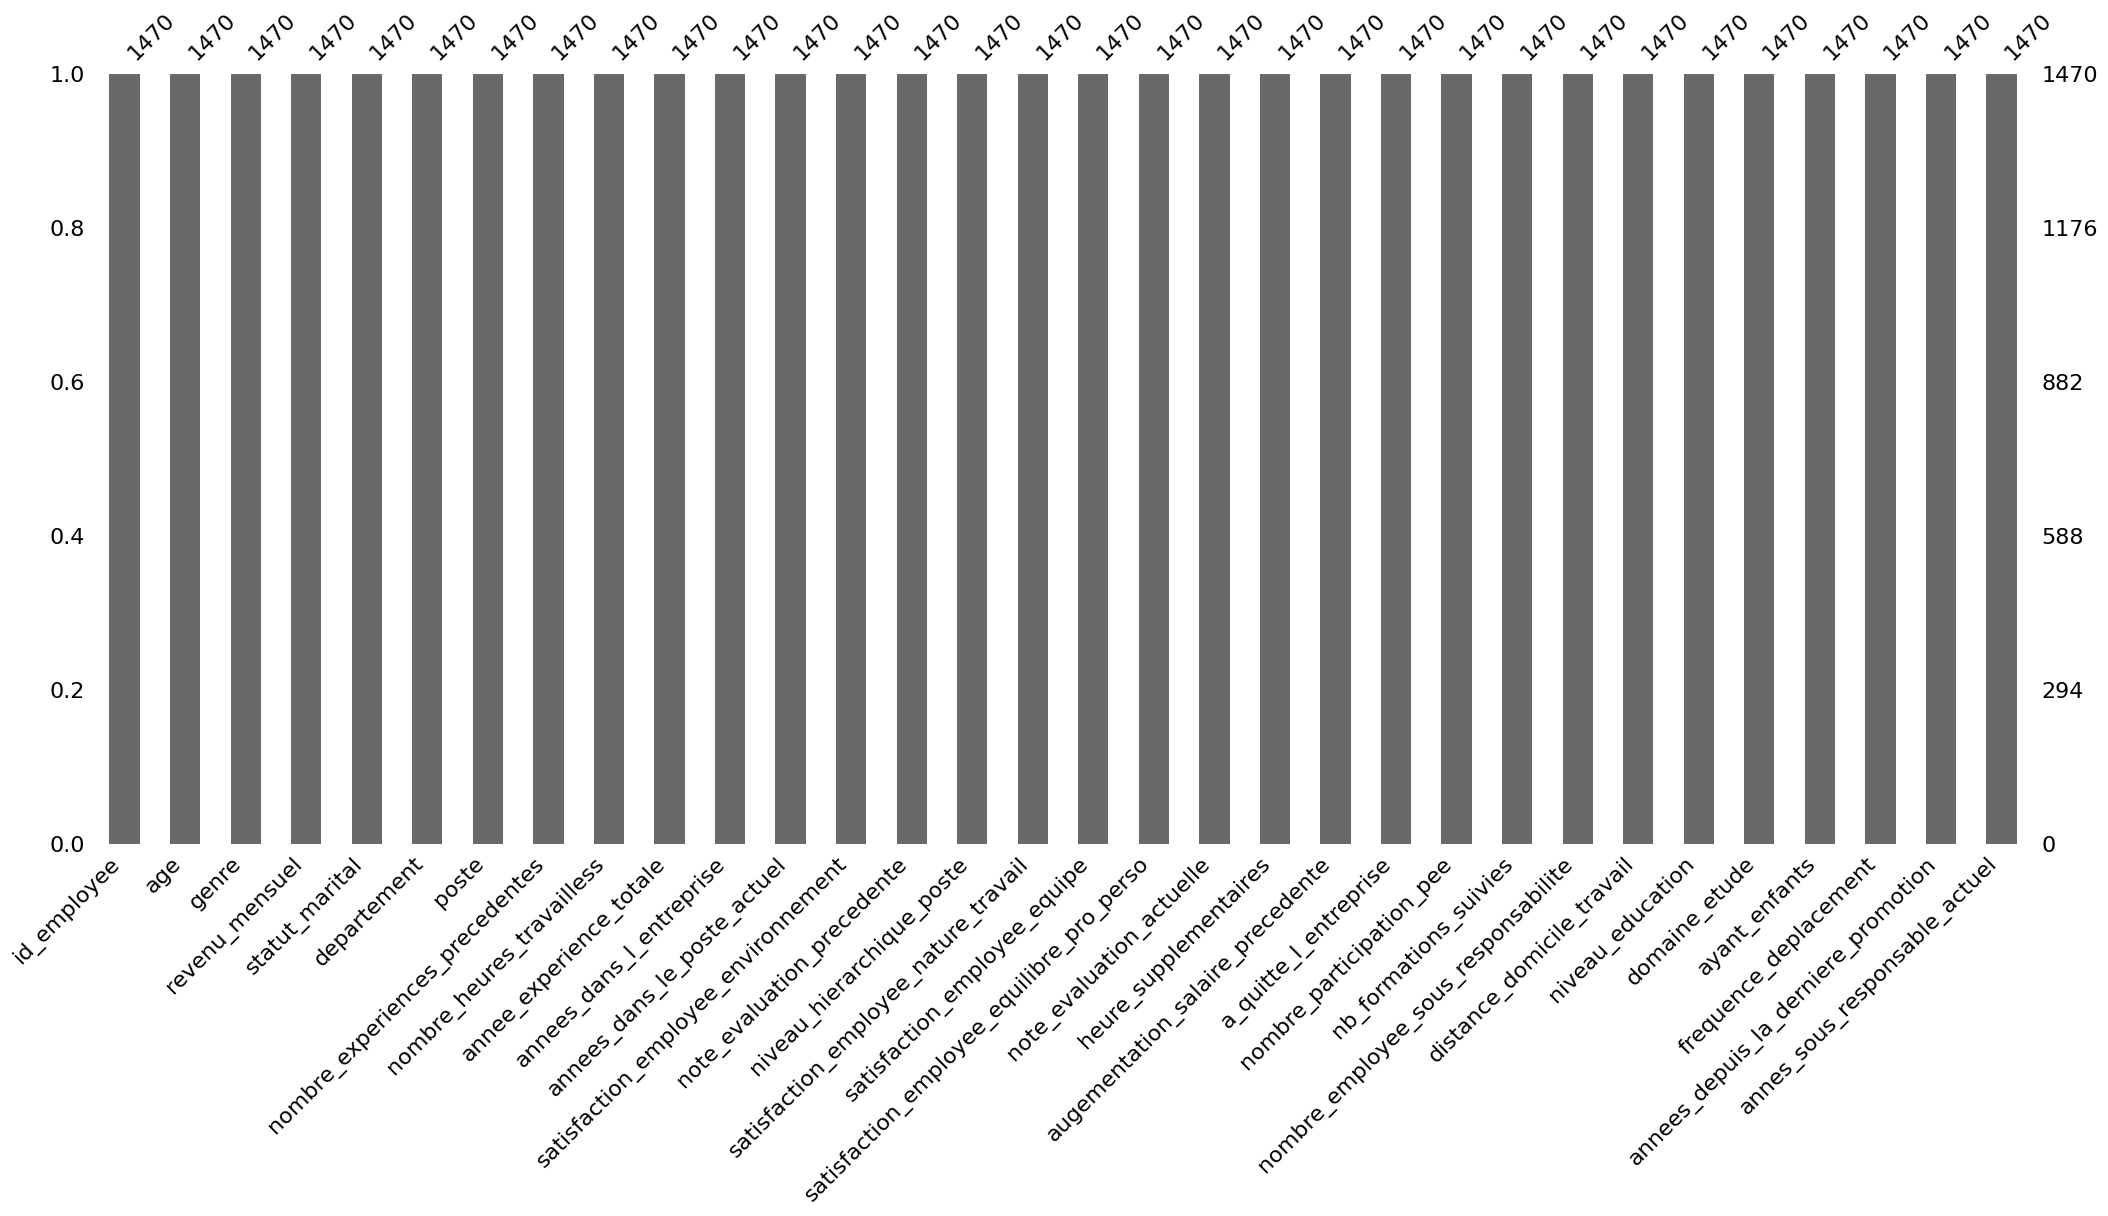

In [10]:
msno.bar(df_merge)

In [11]:
df_merge['a_quitte_l_entreprise'].value_counts()

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

In [12]:
df_merge['departement'].value_counts()

departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

In [13]:
df_merge['poste'].value_counts()

poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

In [14]:
df_merge['domaine_etude'].value_counts()

domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64

In [15]:
def make_countplot(df, x_axis, y_axis):
    plt.figure(figsize=(15, 6))
    ax = sns.countplot(x=x_axis, hue=y_axis, data=df)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.legend_.set_title("A quitté l'entreprise \n (Oui : 1 / Non : 0)")

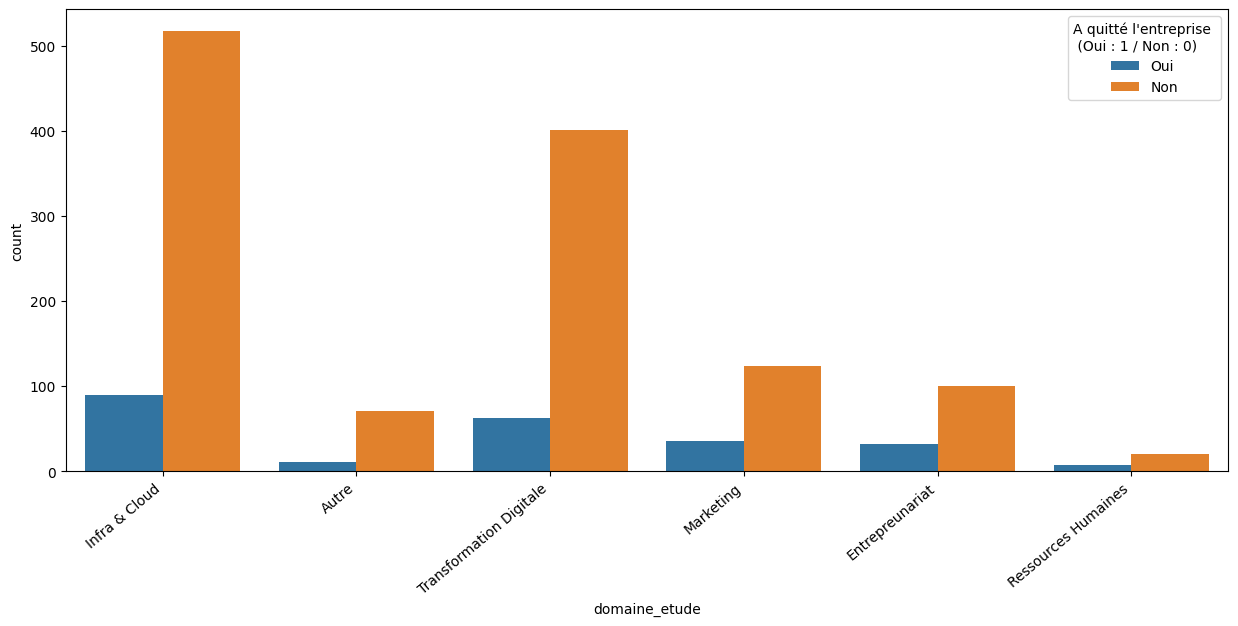

In [16]:
make_countplot(df_merge, "domaine_etude", "a_quitte_l_entreprise")

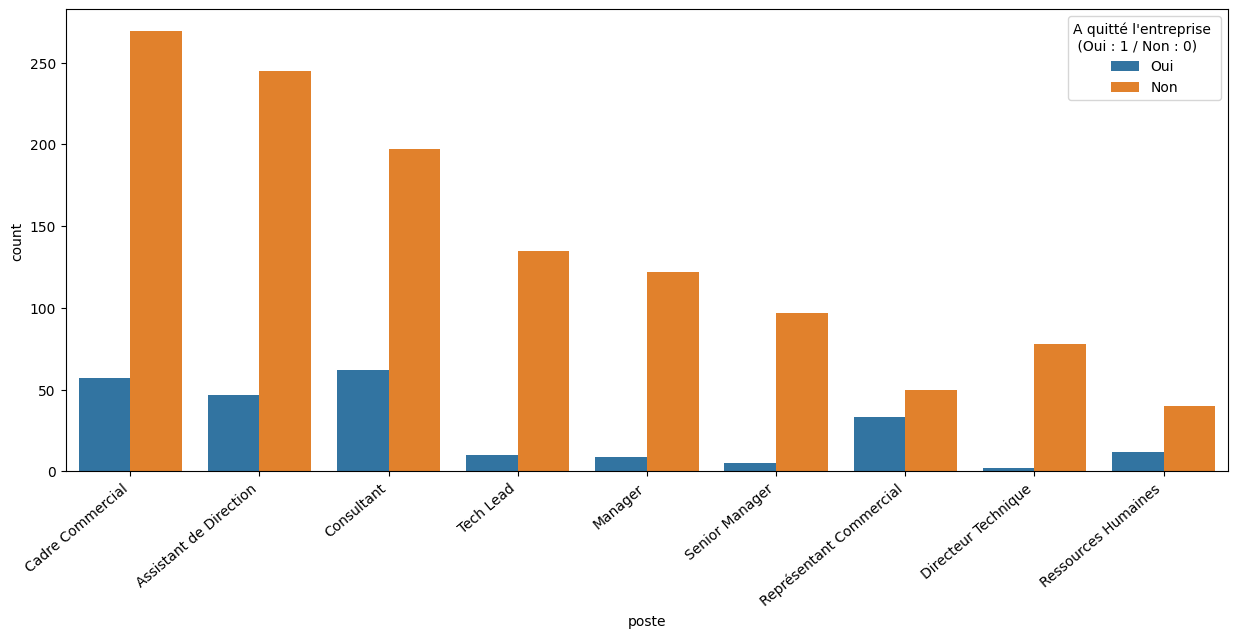

In [17]:
make_countplot(df_merge, "poste", "a_quitte_l_entreprise")

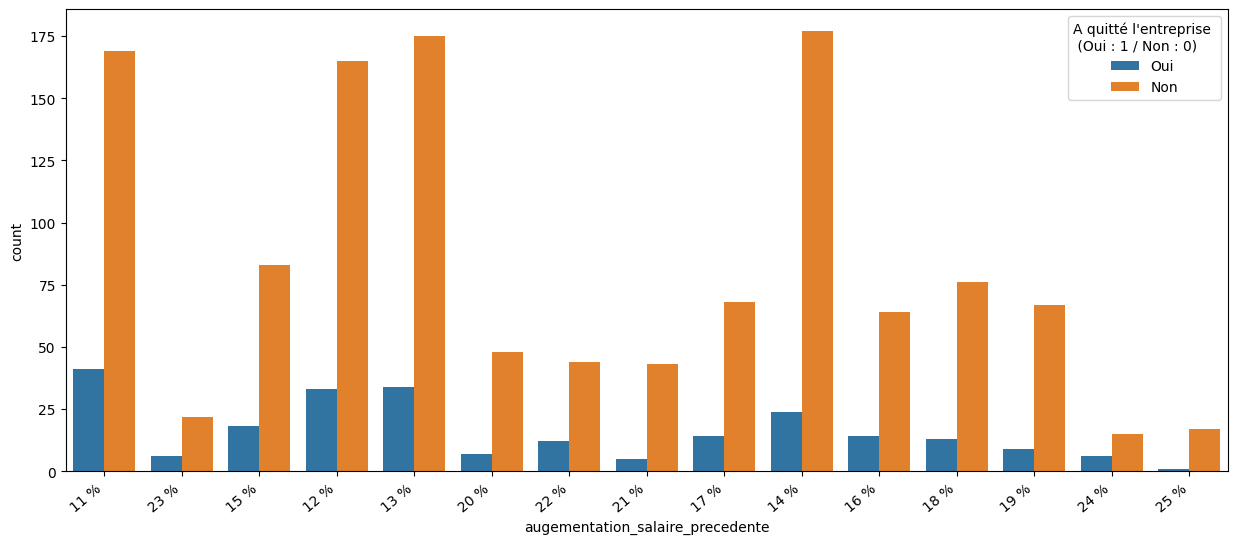

In [18]:
make_countplot(df_merge, "augementation_salaire_precedente", "a_quitte_l_entreprise")

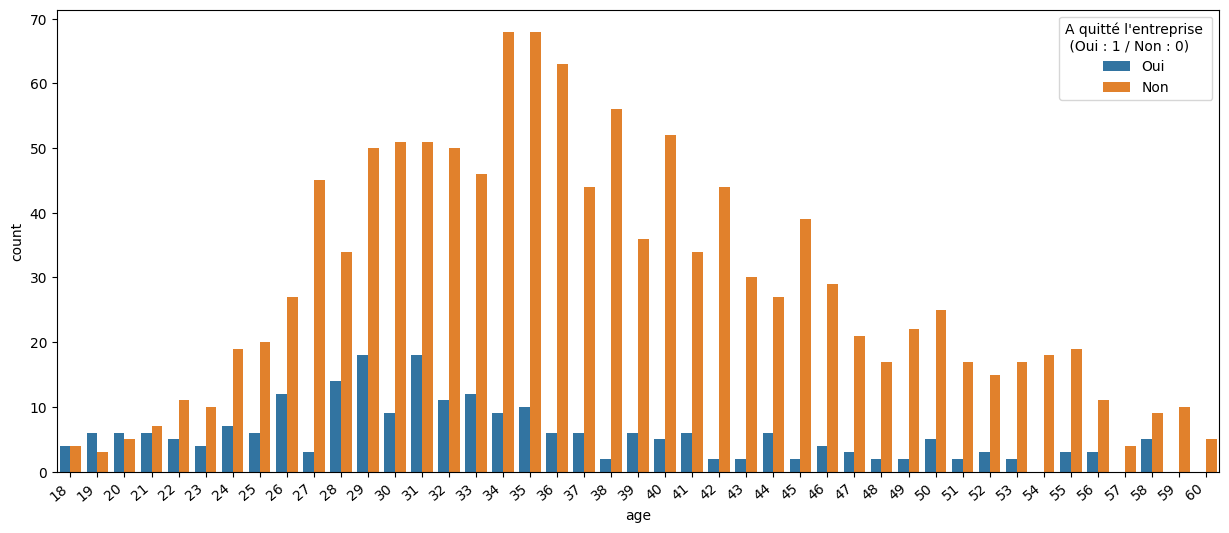

In [19]:
make_countplot(df_merge, "age", "a_quitte_l_entreprise")

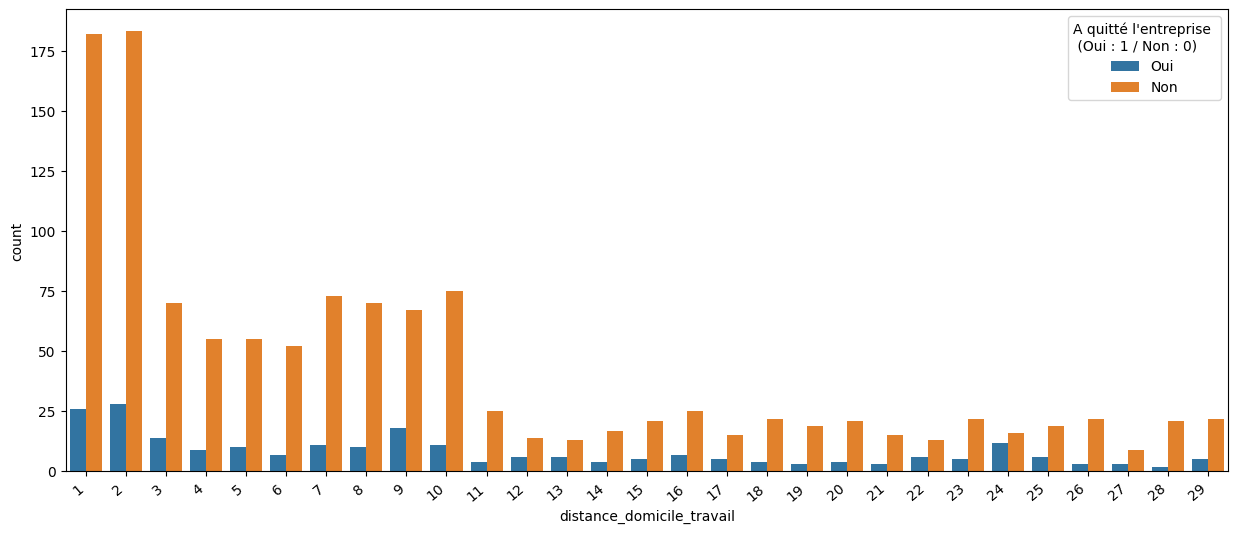

In [20]:
make_countplot(df_merge, "distance_domicile_travail", "a_quitte_l_entreprise")

### Feature Engineering

In [21]:
#remplacer les H et F du dataframe par 0 ou 1 
df_merge["genre"] = df_merge["genre"].map({'F': 0, 'M': 1})
df_merge["ayant_enfants"] = df_merge["ayant_enfants"].map({'Y': 0, 'N': 1})
df_merge["heure_supplementaires"] = df_merge["heure_supplementaires"].map({'Oui': 0, 'Non': 1})
df_merge["a_quitte_l_entreprise"] = df_merge["a_quitte_l_entreprise"].map({'Oui': 1, 'Non': 0})
df_merge = df_merge.drop("nombre_heures_travailless", axis=1)
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,0,5993,Célibataire,Commercial,Cadre Commercial,8,8,6,4,2,3,2,4,1,1,3,0,11 %,1,0,0,1,1,2,Infra & Cloud,0,Occasionnel,0,5
1,2,49,1,5130,Marié(e),Consulting,Assistant de Direction,1,10,10,7,3,2,2,2,4,3,4,1,23 %,0,1,3,1,8,1,Infra & Cloud,0,Frequent,1,7
2,4,37,1,2090,Célibataire,Consulting,Consultant,6,7,0,0,4,2,1,3,2,3,3,0,15 %,1,0,3,1,2,2,Autre,0,Occasionnel,0,0
3,5,33,0,2909,Marié(e),Consulting,Assistant de Direction,1,8,8,7,4,3,1,3,3,3,3,0,11 %,0,0,3,1,3,4,Infra & Cloud,0,Frequent,3,0
4,7,27,1,3468,Marié(e),Consulting,Consultant,9,6,2,2,1,3,1,2,4,3,3,1,12 %,0,1,3,1,2,1,Transformation Digitale,0,Occasionnel,2,2


In [22]:
df_merge["id_employee"] = df_merge["id_employee"].astype(int)

In [23]:
df_merge['augementation_salaire_precedente'] = df_merge['augementation_salaire_precedente'].str.rstrip('%').astype(float) / 100

In [24]:
df_merge['augementation_salaire_precedente'].value_counts()

augementation_salaire_precedente
0.11    210
0.13    209
0.14    201
0.12    198
0.15    101
0.18     89
0.17     82
0.16     78
0.19     76
0.22     56
0.20     55
0.21     48
0.23     28
0.24     21
0.25     18
Name: count, dtype: int64

In [25]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   int64  
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   annee_experience_totale                    1470 non-null   int64  
 9   annees_dans_l_entreprise                   1470 non-null   int64  
 10  annees_dans_le_poste_act

In [26]:
#colonne a encodé frequence_deplacement, domaine_etude, poste, departement, statut_marital
def encode_column_with_onehot(df, column_name, max_categories=100):
    # Initialiser le OneHotEncoder
    if column_name not in df.columns:
        print(f"La colonne '{column_name}' n'existe pas dans le DataFrame.")
        return df  # Retourner le DataFrame original sans modification
    encoder = OneHotEncoder(sparse_output=False, drop='first', max_categories=max_categories)  # drop='first' pour éviter la multicolinéarité
    # Appliquer l'encodage sur la colonne spécifiée
    encoded_array = encoder.fit_transform(df[[column_name]])
    # Récupérer les noms des colonnes encodées
    encoded_cols = encoder.get_feature_names_out([column_name])
    # Créer un DataFrame avec les colonnes encodées
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index) # faire en sorte que les colonne soit encodé en object ou int 
    # Supprimer la colonne originale
    df = df.drop(columns=[column_name])
    # Concaténer le DataFrame original avec les colonnes encodées
    df_final = pd.concat([df, df_encoded], axis=1)
    return df_final



In [27]:
df = encode_column_with_onehot(df_merge, "frequence_deplacement")
df = encode_column_with_onehot(df, "domaine_etude")
df = encode_column_with_onehot(df, "poste")
df = encode_column_with_onehot(df, "departement")
df = encode_column_with_onehot(df, "statut_marital")

### Modélisation

In [28]:
# CODE PREPARATION DES FEATURES
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
from imblearn.over_sampling import SMOTE



In [29]:
def modele_classification(df, target_col, modele_type):
    # Séparer les features et la cible
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    # Diviser en train et test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # SMOTE
    smote = SMOTE(sampling_strategy='minority', random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # Vérification de l'équilibre après SMOTE
    print("Répartition avant SMOTE :")
    print(y_train.value_counts())

    print("Répartition après SMOTE :")
    print(y_resampled.value_counts())


    # Choisir le modèle
    if modele_type == 'logisticregression':
        model = LogisticRegression(max_iter=5000, class_weight="balanced")
    elif modele_type == 'dummyclassifier':
        model = DummyClassifier(strategy='most_frequent')
    elif modele_type == 'svc':
        model = SVC(probability=True, class_weight='balanced')
    elif modele_type == 'randomforestclassifier':
        model = RandomForestClassifier(random_state=42, class_weight="balanced")
    elif modele_type == 'xgboost':
        model = xgb.XGBClassifier(random_state=42)
    else:
        raise ValueError("Type de modèle non reconnu. Choisissez parmi : 'logisticregression', 'dummyclassifier', 'svc', 'randomforestclassifier', 'xgboost'.")
    
    # Entraîner le modèle -> Données resample ?
    model.fit(X_train, y_train)

    # Entraîner le modèle -> Données resample ?
    #model.fit(X_resampled, y_resampled)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    print(f"===== RÉSULTATS POUR : {modele_type} =====")
    
    # 2. Matrice de confusion (calcul)
    cm = confusion_matrix(y_test, y_pred)
    
    # 3. Matrice de confusion (Visualisation avec Seaborn)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=False, annot_kws={"size": 14})
    plt.title(f'Matrice de Confusion - {modele_type}')
    plt.ylabel('Vraie valeur (Actual)')
    plt.xlabel('Prédiction (Predicted)')
    plt.show()
    print("=" * (30 + len(modele_type)))
    
    # 2. Rapport de classification (inclut Précision, Rappel, F1-Score)
    print(f"\nRapport de Classification :")
    report = classification_report(y_test, y_pred)
    print(report)

    
    return y_test, y_pred

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64
===== RÉSULTATS POUR : dummyclassifier =====


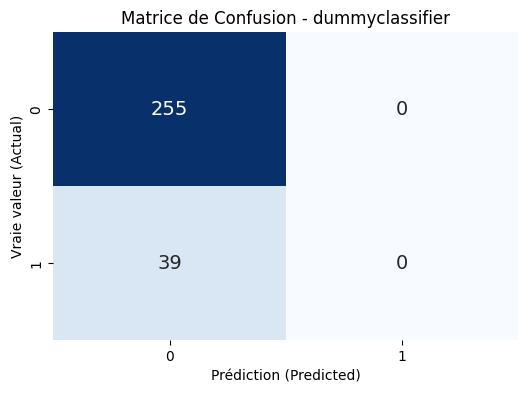


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       255
           1       0.00      0.00      0.00        39

    accuracy                           0.87       294
   macro avg       0.43      0.50      0.46       294
weighted avg       0.75      0.87      0.81       294



In [30]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'dummyclassifier')

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64


===== RÉSULTATS POUR : randomforestclassifier =====


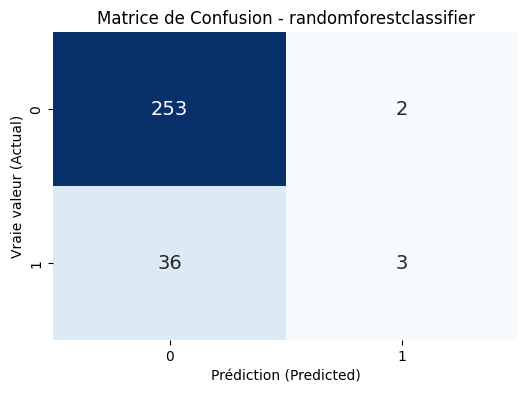


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.60      0.08      0.14        39

    accuracy                           0.87       294
   macro avg       0.74      0.53      0.53       294
weighted avg       0.84      0.87      0.82       294



In [31]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'randomforestclassifier')

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64


===== RÉSULTATS POUR : logisticregression =====


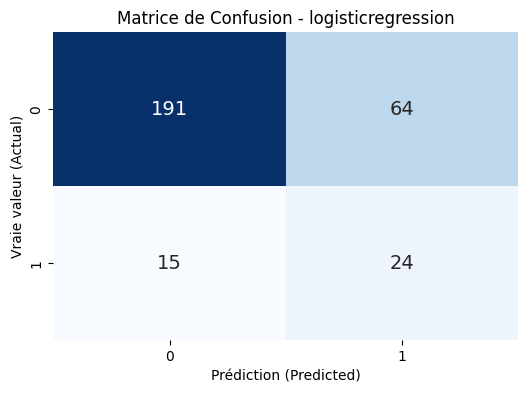


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.93      0.75      0.83       255
           1       0.27      0.62      0.38        39

    accuracy                           0.73       294
   macro avg       0.60      0.68      0.60       294
weighted avg       0.84      0.73      0.77       294



In [32]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'logisticregression')

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64
===== RÉSULTATS POUR : svc =====


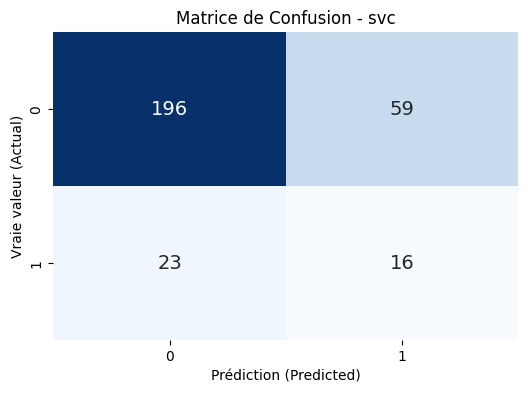


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.89      0.77      0.83       255
           1       0.21      0.41      0.28        39

    accuracy                           0.72       294
   macro avg       0.55      0.59      0.55       294
weighted avg       0.80      0.72      0.75       294



In [33]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'svc')

Répartition avant SMOTE :
a_quitte_l_entreprise
0    978
1    198
Name: count, dtype: int64
Répartition après SMOTE :
a_quitte_l_entreprise
0    978
1    978
Name: count, dtype: int64
===== RÉSULTATS POUR : xgboost =====


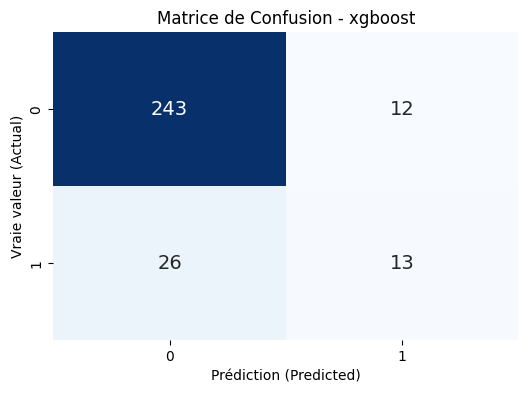


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       255
           1       0.52      0.33      0.41        39

    accuracy                           0.87       294
   macro avg       0.71      0.64      0.67       294
weighted avg       0.85      0.87      0.86       294



In [34]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'xgboost')

In [ ]:
import pprint
from sklearn.model_selection import cross_validate

X_rh = df.drop('a_quitte_l_entreprise', axis=1)
y_rh = df['a_quitte_l_entreprise']
X_train, X_test, y_train, y_test = train_test_split(X_rh, y_rh, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(max_depth=5)

scores = cross_validate(model, X_rh, y_rh, cv=5, scoring=('accuracy', 'precision', 'recall', "f1_weighted", "f1_macro" ), return_train_score=True)
pprint.pprint(scores)

#moyenne et ecart type a rajouter 

{'fit_time': array([4.19320536, 1.45682716, 0.16374731, 0.37669706, 2.86718225]),
 'score_time': array([0.01845407, 0.02219129, 0.0225637 , 0.01561856, 0.01331019]),
 'test_accuracy': array([0.86734694, 0.8537415 , 0.8537415 , 0.86394558, 0.85034014]),
 'test_f1_macro': array([0.64332597, 0.64697998, 0.69216159, 0.65865552, 0.55139409]),
 'test_f1_weighted': array([0.83369572, 0.82893011, 0.84387981, 0.83873452, 0.8005158 ]),
 'test_precision': array([0.84615385, 0.61904762, 0.55882353, 0.68421053, 0.71428571]),
 'test_recall': array([0.22916667, 0.27083333, 0.40425532, 0.27659574, 0.10638298]),
 'train_accuracy': array([1., 1., 1., 1., 1.]),
 'train_f1_macro': array([1., 1., 1., 1., 1.]),
 'train_f1_weighted': array([1., 1., 1., 1., 1.]),
 'train_precision': array([1., 1., 1., 1., 1.]),
 'train_recall': array([1., 1., 1., 1., 1.])}


In [36]:

import shap
X_rh = df.drop('a_quitte_l_entreprise', axis=1)
y_rh = df['a_quitte_l_entreprise']
X_train, X_test, y_train, y_test = train_test_split(X_rh, y_rh, test_size=0.2, random_state=42)
model = xgb.XGBClassifier()
model.fit(X_train, y_train)
model

df.info()
df.head(1000)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 45 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   int64  
 3   revenu_mensuel                             1470 non-null   int64  
 4   nombre_experiences_precedentes             1470 non-null   int64  
 5   annee_experience_totale                    1470 non-null   int64  
 6   annees_dans_l_entreprise                   1470 non-null   int64  
 7   annees_dans_le_poste_actuel                1470 non-null   int64  
 8   satisfaction_employee_environnement        1470 non-null   int64  
 9   note_evaluation_precedente                 1470 non-null   int64  
 10  niveau_hierarchique_post

,id_employee,age,genre,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,ayant_enfants,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,frequence_deplacement_Frequent,frequence_deplacement_Occasionnel,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,departement_Consulting,departement_Ressources Humaines,statut_marital_Divorcé(e),statut_marital_Marié(e)
0,1,41,0,5993,8,8,6,4,2,3,2,4,1,1,3,0,0.11,1,0,0,1,1,2,0,0,5,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,49,1,5130,1,10,10,7,3,2,2,2,4,3,4,1,0.23,0,1,3,1,8,1,0,1,7,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,4,37,1,2090,6,7,0,0,4,2,1,3,2,3,3,0,0.15,1,0,3,1,2,2,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,5,33,0,2909,1,8,8,7,4,3,1,3,3,3,3,0,0.11,0,0,3,1,3,4,0,3,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,7,27,1,3468,9,6,2,2,1,3,1,2,4,3,3,1,0.12,0,1,3,1,2,1,0,2,2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1402,43,0,4081,1,20,20,7,1,2,2,3,1,1,3,0,0.14,0,0,3,1,6,3,0,1,8,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
996,1403,27,0,5769,1,6,6,2,4,2,2,4,4,3,3,0,0.11,0,0,3,1,10,3,0,4,4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
997,1405,27,0,2394,1,8,8,2,4,3,1,3,4,3,3,0,0.13,1,0,2,1,17,4,0,7,7,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
998,1407,26,1,3904,0,5,4,3,1,2,1,4,4,3,3,1,0.12,0,0,2,1,2,1,0,1,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [37]:
model.predict(X_test)
#df = df.astype(object)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

In [38]:
y_train

1097    0
727     0
254     0
1175    0
1341    0
       ..
1130    0
1294    0
860     1
1459    0
1126    0
Name: a_quitte_l_entreprise, Length: 1176, dtype: int64

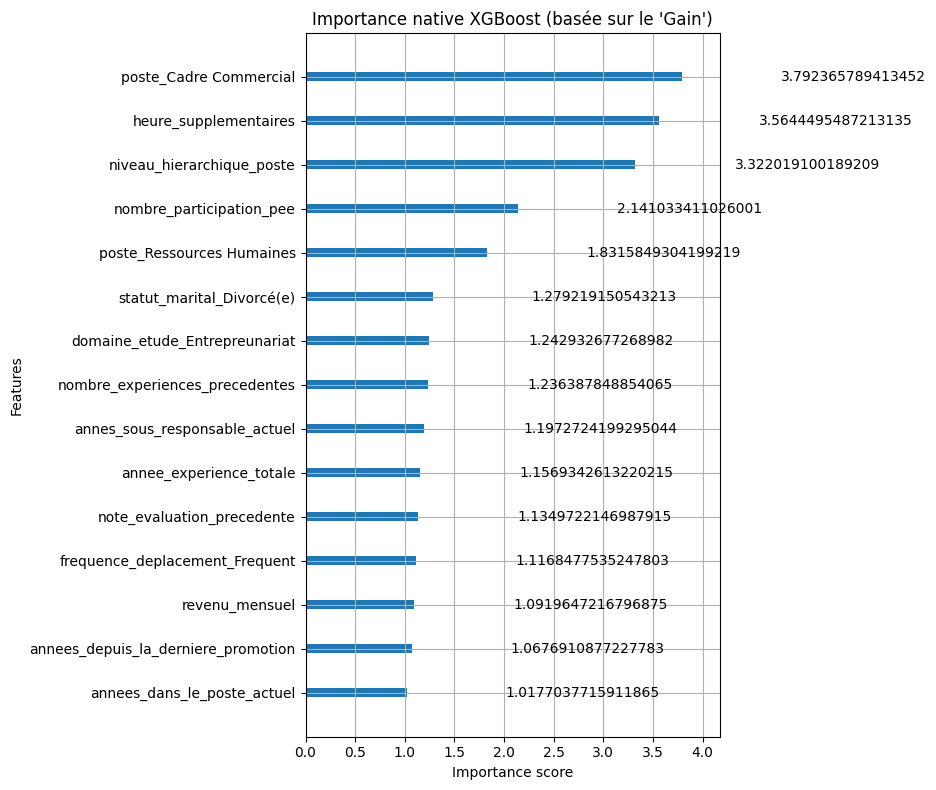

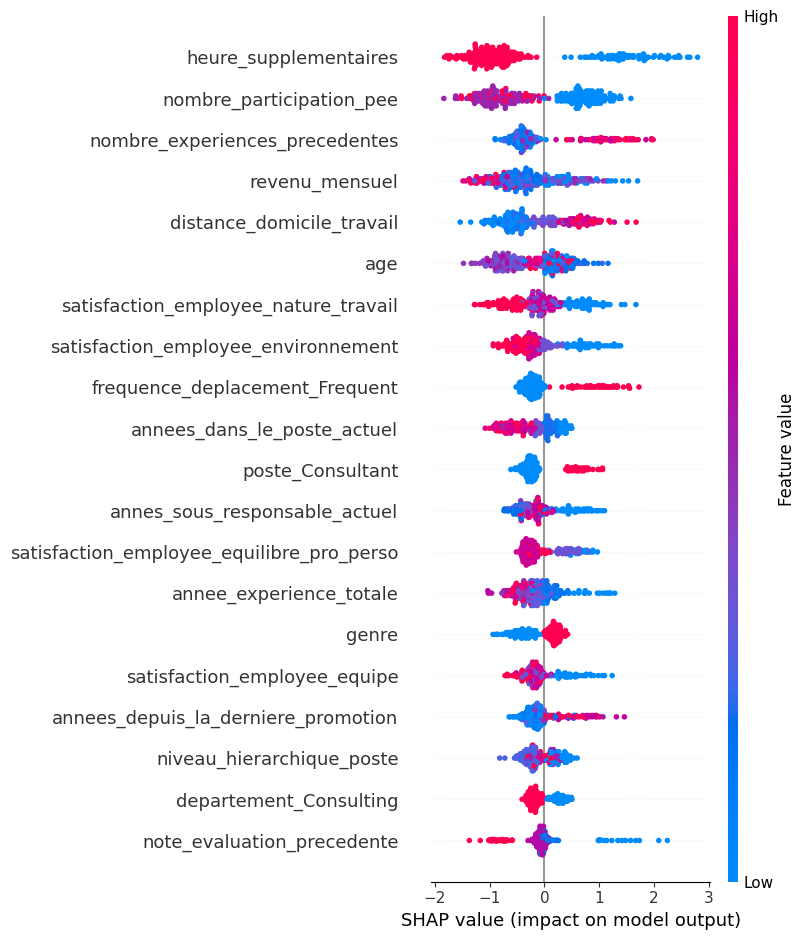

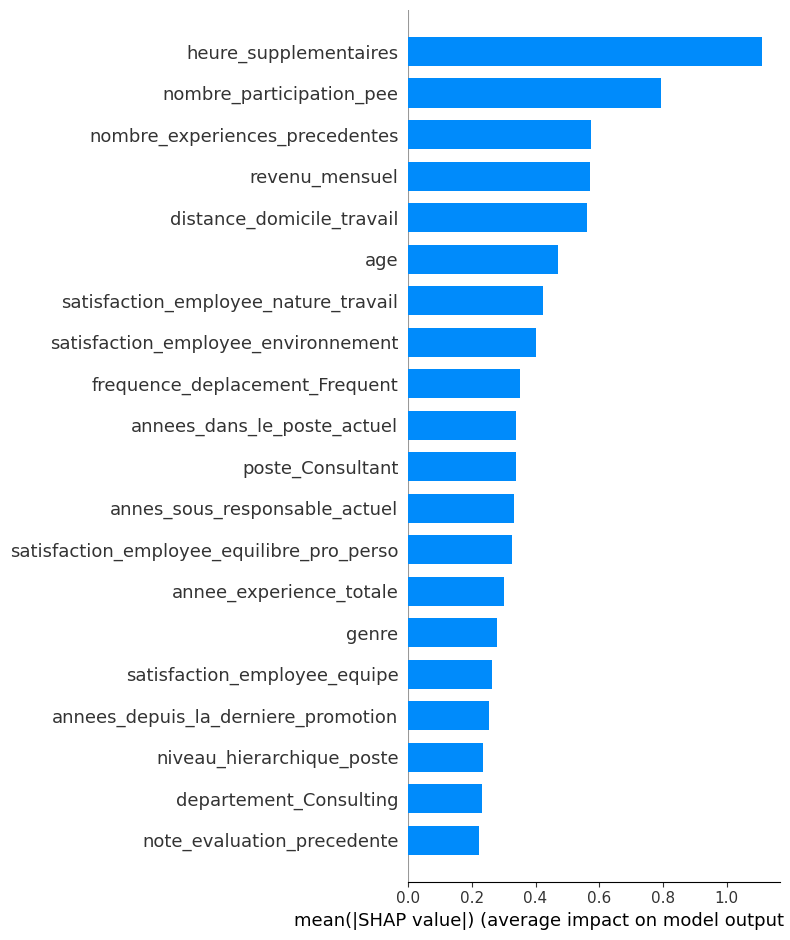

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(model, 
                    ax=ax, 
                    importance_type='gain', 
                    max_num_features=15, # Afficher le top 15
                    title="Importance native XGBoost (basée sur le 'Gain')")
plt.tight_layout()
plt.show()

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
# Définir la grille d'hyperparamètres à tester
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [175, 200, 215],
    'subsample': [0.5, 0.6, 0.7],
    'colsample_bytree': [0.5, 0.6, 0.7]
}

# Configurer la recherche par grille
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=10)

# Lancer la recherche
grid_search.fit(X_train, y_train)

# Meilleur hyperparamètre
print("Meilleurs hyperparamètres :", grid_search.best_params_)

# Évaluer le meilleur modèle sur le test
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
#print("Accuracy sur le test :", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 2000 candidates, totalling 10000 fits
[CV 1/5; 1/2000] START colsample_bytree=0.5, learning_rate=0.01, max_depth=1, n_estimators=50, subsample=0.5
[CV 1/5; 1/2000] END colsample_bytree=0.5, learning_rate=0.01, max_depth=1, n_estimators=50, subsample=0.5;, score=0.831 total time=   0.0s
[CV 2/5; 1/2000] START colsample_bytree=0.5, learning_rate=0.01, max_depth=1, n_estimators=50, subsample=0.5
[CV 2/5; 1/2000] END colsample_bytree=0.5, learning_rate=0.01, max_depth=1, n_estimators=50, subsample=0.5;, score=0.834 total time=   0.0s
[CV 3/5; 1/2000] START colsample_bytree=0.5, learning_rate=0.01, max_depth=1, n_estimators=50, subsample=0.5
[CV 3/5; 1/2000] END colsample_bytree=0.5, learning_rate=0.01, max_depth=1, n_estimators=50, subsample=0.5;, score=0.834 total time=   0.0s
[CV 4/5; 1/2000] START colsample_bytree=0.5, learning_rate=0.01, max_depth=1, n_estimators=50, subsample=0.5
[CV 4/5; 1/2000] END colsample_bytree=0.5, learning_rate=0.01, max_depth=1, n_

Meilleurs hyperparamètres : {'colsample_bytree': 1, 'learning_rate': 0.15, 'max_depth': 1, 'n_estimators': 200, 'subsample': 0.6}

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score




def grid_search_with_cv_metrics(model, param_grid, X, y, scoring='accuracy', cv=5):
    # Créer le GridSearchCV avec validation croisée intégrée
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=cv, return_train_score=False, verbose=1)
    
    # Effectuer la recherche
    grid.fit(X, y)
    
    #cv_results = grid.cv_results_
    # Les scores par fold sont dans 'splitX_test_score' (X étant le fold index)
    # Cependant, pour la plupart des métriques, ce n'est pas directement stocké
    # Donc, pour obtenir les scores par fold, on peut faire une validation croisée manuelle
    # ou utiliser la méthode cross_val_score pour chaque hyperparamètre
    # Ici, on va faire une validation croisée manuelle pour stocker les métriques
    
    # Alternativement, si vous souhaitez uniquement la moyenne et l'écart-type, utilisez cross_val_score
    
    
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    
    # Calculer la moyenne et l'écart-type
    mean_score = np.mean(scores)
    std_score = np.std(scores)
    
    print(f"Métrique moyenne : {mean_score:.3f}")
    print(f"Écart-type : {std_score:.3f}")
    
    return scores, mean_score, std_score

In [ ]:
grid_search_with_cv_metrics(model, param_grid, X_rh, y_rh, scoring="accuracy", cv=5)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Métrique moyenne : 0.863
Écart-type : 0.006


(array([0.86394558, 0.86394558, 0.8537415 , 0.8707483 , 0.86054422]),
 np.float64(0.8625850340136054),
 np.float64(0.005526556737847598))